<a href="https://colab.research.google.com/github/Parama-Dey/Dimensionality_Reduction_TMP/blob/main/PCA_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PCA Implementation**

##**Notebook structure**

**1.Importing Necessary Libraries**

**2.Importing The Dataset**

**3.Data Cleaning and Preprocessing**

**4.Initial Analysis**

**5.Identifying missing values in the dataset**

**6.Dropping the unnecessary columns**

**7.Univariate analysis of numerical columns(except student_id)**

**8.Feature scaling**

**9.Implementation of the PCA Model**

**10.Visualization of the PCA components**

**1.Importing necessary library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2.Importing the dataset**

In [ ]:
df=pd.read_csv("student_grades.csv")

**3.Data cleaning and preprocessing**

In [ ]:
# Check for duplicates
print('Number of rows in the dataset at initial stage:',len(df))
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate entries: {duplicate_count}")

Number of rows in the dataset at initial stage: 100

Duplicate entries: 0


So, there are no duplicate entries present in the dataset

**4.Initial analysis**

In [ ]:
df.shape

(100, 9)

In [ ]:
df.columns

Index(['student_id', 'math', 'science', 'cs', 'band', 'english', 'history',
       'spanish', 'physed'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  100 non-null    int64
 1   math        100 non-null    int64
 2   science     100 non-null    int64
 3   cs          100 non-null    int64
 4   band        100 non-null    int64
 5   english     100 non-null    int64
 6   history     100 non-null    int64
 7   spanish     100 non-null    int64
 8   physed      100 non-null    int64
dtypes: int64(9)
memory usage: 7.2 KB


In [ ]:
df.head()

,student_id,math,science,cs,band,english,history,spanish,physed
0,1,46,48,50,74,34,44,39,73
1,2,66,65,65,66,74,80,75,63
2,3,55,53,50,76,71,72,76,71
3,4,53,57,53,80,77,77,85,82
4,5,55,62,58,67,82,77,78,60


In [ ]:
df.describe()

,student_id,math,science,cs,band,english,history,spanish,physed
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,53.050000,53.220000,52.750000,70.04000,60.970000,63.600000,65.560000,67.610000
std,29.011492,13.912697,14.003304,13.462537,6.27794,17.307939,17.476102,18.405269,8.069014
min,1.000000,21.000000,22.000000,28.000000,60.00000,30.000000,28.000000,31.000000,51.000000
25%,25.750000,45.000000,44.750000,44.000000,64.00000,48.000000,50.750000,49.500000,62.750000
50%,50.500000,51.500000,52.000000,50.000000,71.00000,60.500000,65.000000,68.500000,67.000000
75%,75.250000,58.000000,59.250000,58.250000,75.00000,74.000000,78.000000,79.000000,74.250000
max,100.000000,93.000000,94.000000,92.000000,80.00000,90.000000,98.000000,99.000000,84.000000


**5.Identifying missing values in the dataset**

In [ ]:
df.isnull().sum()

,0
student_id,0
math,0
science,0
cs,0
band,0
english,0
history,0
spanish,0
physed,0


There are no missing (NaN/Null) values present in the dataset

**6.Dropping the unnecessary columns**

In [ ]:
df_necessary=df.drop(columns=['student_id'])

In [ ]:
df_necessary.head()

,math,science,cs,band,english,history,spanish,physed
0,46,48,50,74,34,44,39,73
1,66,65,65,66,74,80,75,63
2,55,53,50,76,71,72,76,71
3,53,57,53,80,77,77,85,82
4,55,62,58,67,82,77,78,60


**7.Univariate analysis of numerical columns(except student_id)**

In [ ]:
df_necessary.describe(include="all")

,math,science,cs,band,english,history,spanish,physed
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,53.050000,53.220000,52.750000,70.04000,60.970000,63.600000,65.560000,67.610000
std,13.912697,14.003304,13.462537,6.27794,17.307939,17.476102,18.405269,8.069014
min,21.000000,22.000000,28.000000,60.00000,30.000000,28.000000,31.000000,51.000000
25%,45.000000,44.750000,44.000000,64.00000,48.000000,50.750000,49.500000,62.750000
50%,51.500000,52.000000,50.000000,71.00000,60.500000,65.000000,68.500000,67.000000
75%,58.000000,59.250000,58.250000,75.00000,74.000000,78.000000,79.000000,74.250000
max,93.000000,94.000000,92.000000,80.00000,90.000000,98.000000,99.000000,84.000000


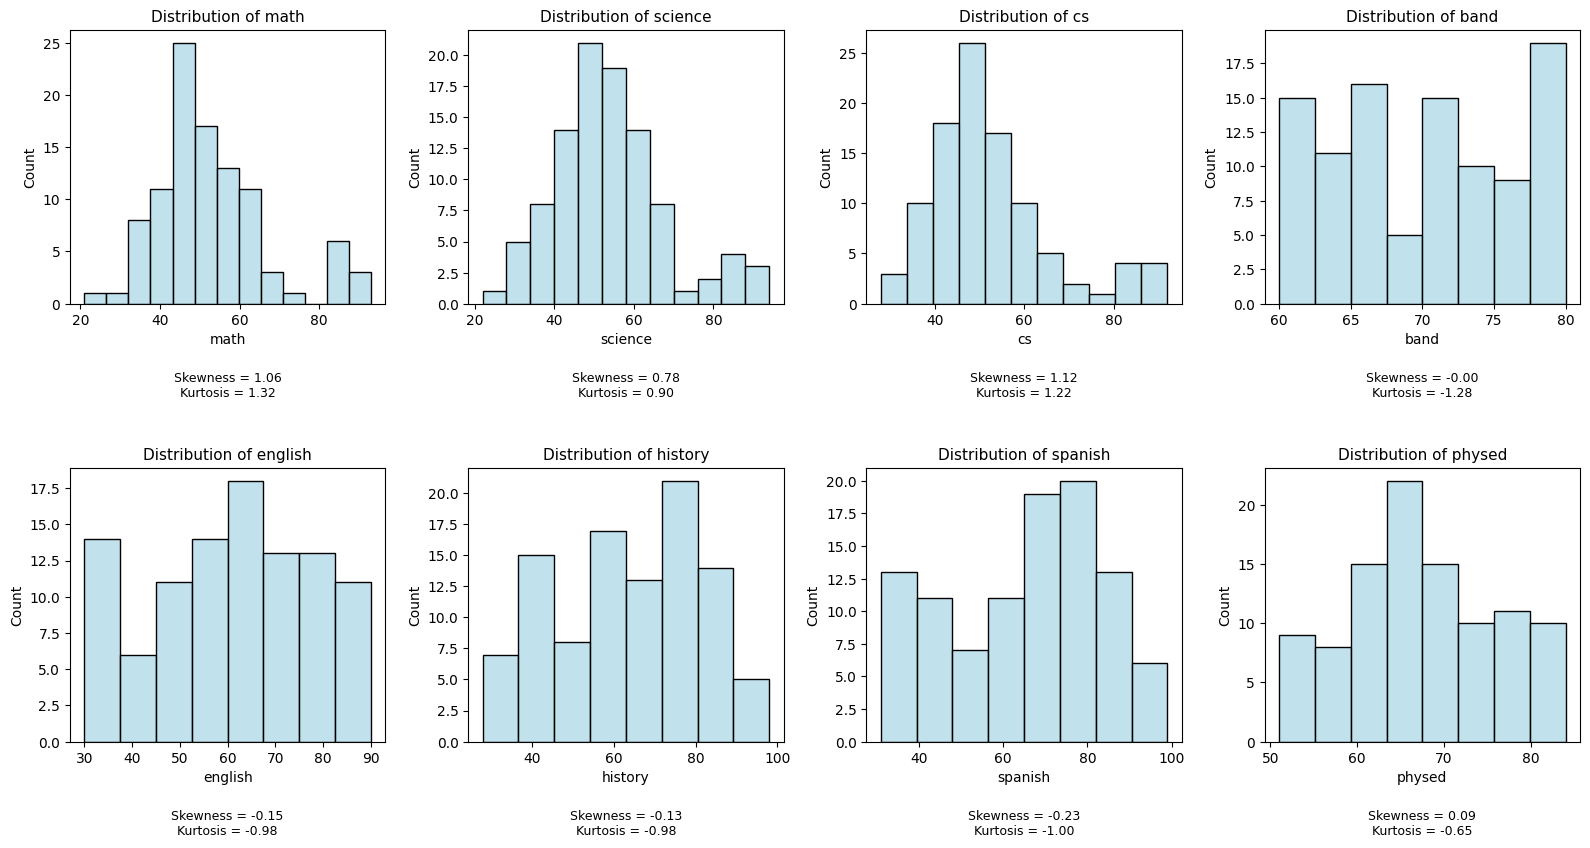

In [ ]:
features_to_check = [
    'math', 'science', 'cs', 'band', 'english', 'history',
       'spanish', 'physed'
]
plt.figure(figsize=(16, 12))

for i, col in enumerate(features_to_check):
    ax = plt.subplot(3, 4, i + 1)  # Create subplot

    # Plot histogram
    sns.histplot(data=df_necessary, x=col, color="lightblue", ax=ax)

    # Calculate skewness & kurtosis
    skew_val = df_necessary[col].skew()
    kurt_val = df_necessary[col].kurt()

    # Add caption below each subplot
    ax.text(0.5, -0.25, f"Skewness = {skew_val:.2f}\nKurtosis = {kurt_val:.2f}",
            transform=ax.transAxes,
            ha="center", va="top", fontsize=9, color="black")

    # Title for each subplot
    ax.set_title(f'Distribution of {col}', fontsize=11)

# Adjust layout to make space for captions
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)  # More vertical space

plt.show()

##**Interpretation**

**​1. STEM Subjects (Math, Science, CS)**

​These distributions are characterized by a unimodal (single peak) shape, suggesting a strong central tendency.

**​Math & CS:** These show the highest positive skewness (1.06 and 1.12 respectively). This indicates that while most students score around the average (40–60), there is a "long tail" of a few students scoring significantly higher (80+).

**​Science:** This is the most "normally" distributed of the group, with a skewness of 0.78. Most students are tightly clustered around the 50-mark.

**​Performance Insight:** In these subjects, the majority of the class is performing at a mediocre level, and high achievers (80+) are outliers rather than the norm.

**​2. Humanities & Social Sciences (English, History, Spanish)**

​These plots are much "flatter" and more spread out compared to the STEM subjects.

**​Bimodal Tendencies:** History and Spanish show signs of being bimodal (having two peaks). For example, in Spanish, there is a peak around 40 and another, higher peak around 80.

**​Performance Insight:** This suggests a "polarized" classroom where one group of students is struggling or disinterested, while another large group is performing very well. Unlike Math, where the "average" student is common, these subjects have fewer "average" students and more "low" or "high" performers.

**​3. Band & Physical Education (PhysEd)**

​These subjects show the most unique distributions in the dataset.

**​Band:** This is the only subject showing negative skewness (-0.00, essentially symmetric but weighted toward the high end). Notice that the x-axis starts at 60. This implies that everyone is passing, and a significant portion of the class is achieving the highest possible marks (75–80).

**​PhysEd:** This distribution is relatively balanced but peaks strongly in the 65–70 range. Like Band, the "floor" for scores is higher (starting at 50) compared to Math or Science (starting at 20).

**8.Feature scaling**

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaler_ft = scaler.fit_transform(df_necessary)

In [ ]:
scaled_data = pd.DataFrame(scaler_ft, columns=df_necessary.columns)
scaled_data.head()

,math,science,cs,band,english,history,spanish,physed
0,-0.509284,-0.374647,-0.205300,0.633958,-1.566095,-1.127182,-1.450335,0.671353
1,0.935494,0.845468,0.914517,-0.646765,0.756626,0.943152,0.515480,-0.574200
2,0.140866,-0.015790,-0.205300,0.954139,0.582422,0.483078,0.570086,0.422242
3,-0.003612,0.271296,0.018664,1.594500,0.930830,0.770624,1.061540,1.792350
4,0.140866,0.630154,0.391936,-0.486675,1.221171,0.770624,0.679298,-0.947865


**9.Implementation of the PCA Model**

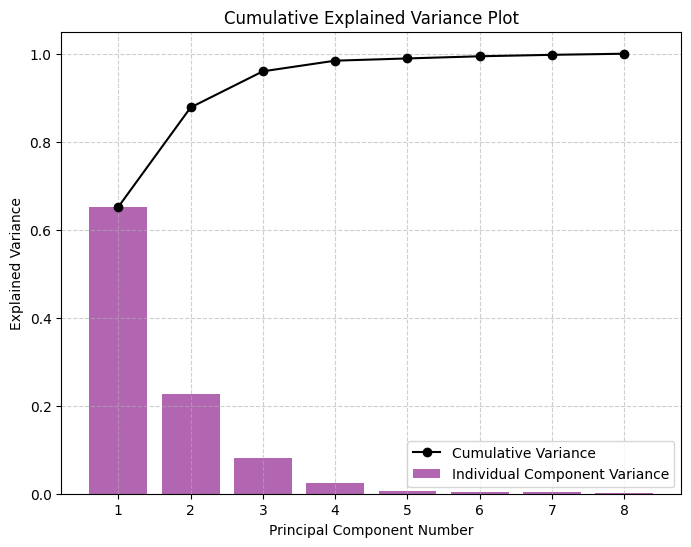

In [ ]:
# Run PCA with all 8 components
pca = PCA(n_components=8)
pca.fit(scaled_data)
# Explained variance ratio for each component
explained_var_ratio = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_var_ratio = np.cumsum(explained_var_ratio)

# Plot
plt.figure(figsize=(8,6))

# Orange bars: individual component variance
plt.bar(range(1, 9), explained_var_ratio, alpha=0.6, color='purple',
        label='Individual Component Variance')

# Blue line: cumulative variance
plt.plot(range(1, 9), cumulative_var_ratio, marker='o', color='black',
         label='Cumulative Variance')

plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance')
plt.title('Cumulative Explained Variance Plot')
plt.xticks(range(1, 9))
plt.ylim(0, 1.05)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Now, based on the above plot, lets stick with 2 Principal Components. It captures nearly 87% of the total differences between students while simplifying 8 subjects down to just 2 easy-to-understand categories (Academic Strength vs. Creative/Physical Strength).

In [ ]:
df_pca_info=pd.DataFrame({
    "Component":range(1,9),
    "Individual Component Vatiance": explained_var_ratio,
    "Cumulative Explained Variance": cumulative_var_ratio
})

In [ ]:
print(df_pca_info)

   Component  Individual Component Vatiance  Cumulative Explained Variance
0          1                       0.651987                       0.651987
1          2                       0.225910                       0.877897
2          3                       0.082115                       0.960011
3          4                       0.024182                       0.984193
4          5                       0.005090                       0.989284
5          6                       0.004905                       0.994189
6          7                       0.003321                       0.997509
7          8                       0.002491                       1.000000


In [ ]:
pca.components_

array([[ 0.41067887,  0.41054002,  0.40545998, -0.00191139,  0.40656736,
         0.40795718,  0.40559114,  0.04656245],
       [ 0.00978021,  0.02873543,  0.02743743,  0.70564179, -0.05172237,
        -0.05162807, -0.03996004,  0.70246566],
       [ 0.39726737,  0.38193738,  0.43736443, -0.0898223 , -0.41175892,
        -0.39660589, -0.41128102, -0.03087159],
       [-0.02743839, -0.02068204, -0.0422048 , -0.69919411, -0.02384487,
        -0.05911541,  0.09012573,  0.70425839],
       [ 0.06289894,  0.08869145, -0.12361694,  0.07102038, -0.26685099,
        -0.5295484 ,  0.78036122, -0.08519339],
       [-0.28988869,  0.64581725, -0.32301456, -0.00346733,  0.49008142,
        -0.35258482, -0.17321307, -0.00596468],
       [ 0.42499482, -0.49669986,  0.06972687,  0.00799989,  0.57520256,
        -0.4774737 , -0.09419645,  0.00554313],
       [-0.63565766, -0.11256295,  0.71923509, -0.00237579,  0.14023751,
        -0.19338023,  0.0937279 , -0.01080644]])

In [ ]:
df_pca_components=pd.DataFrame(pca.components_,columns=df_necessary.columns,index=range(1,9))
df_pca_components.head(2)

,math,science,cs,band,english,history,spanish,physed
1,0.410679,0.410540,0.405460,-0.001911,0.406567,0.407957,0.405591,0.046562
2,0.009780,0.028735,0.027437,0.705642,-0.051722,-0.051628,-0.039960,0.702466


**Here is the breakdown of these two components:**

**​1. Principal Component 1 (PC1):** General Academic Ability
​Looking at the first row (index 1), almost all the subjects have high,

**positive weights (around 0.40 to 0.41):** ​Math, Science, CS, English, History, Spanish are all heavily weighted.​Band and Physed have near-zero weights (-0.001 and 0.046).

**​Insight:** PC1 measures a student's performance in "Traditional Academics." If a student is far to the right on the x-axis, they are doing well across all core subjects. If they are to the left, they are likely struggling across the board academically.

**​2. Principal Component 2 (PC2):** Extracurricular & Physical Focus

**​The second row (index 2) shows a completely different story:**
​Band (0.705) and Physed (0.702) have very high positive weights.
​All academic subjects have weights near zero or slightly negative (e.g., English at -0.05).

**​Insight:** PC2 is a "Non-Academic" or "Creative/Physical" component. It ignores grades in Math or History and focuses almost entirely on how well a student performs in Band and PE.

In [ ]:
# Transform the data, then take only the first two columns [:, 0:2]
pca_transformed = pca.transform(scaled_data)[:, 0:2]

df_transformed = pd.DataFrame(
    pca_transformed,
    columns=['pc1', 'pc2']
)
df_transformed.head()

,pc1,pc2
0,-2.100960,1.094722
1,1.978045,-0.909630
2,0.651055,0.887337
3,1.321249,2.262133
4,1.518651,-1.109114


**10.Visualization of the PCA components**

In [ ]:
# Re-initialize PCA to only find 2 components
pca_2 = PCA(n_components=2)
transformed_data = pca_2.fit_transform(scaled_data)

df_transformed = pd.DataFrame(
    transformed_data,
    columns=['pc1', 'pc2']
)

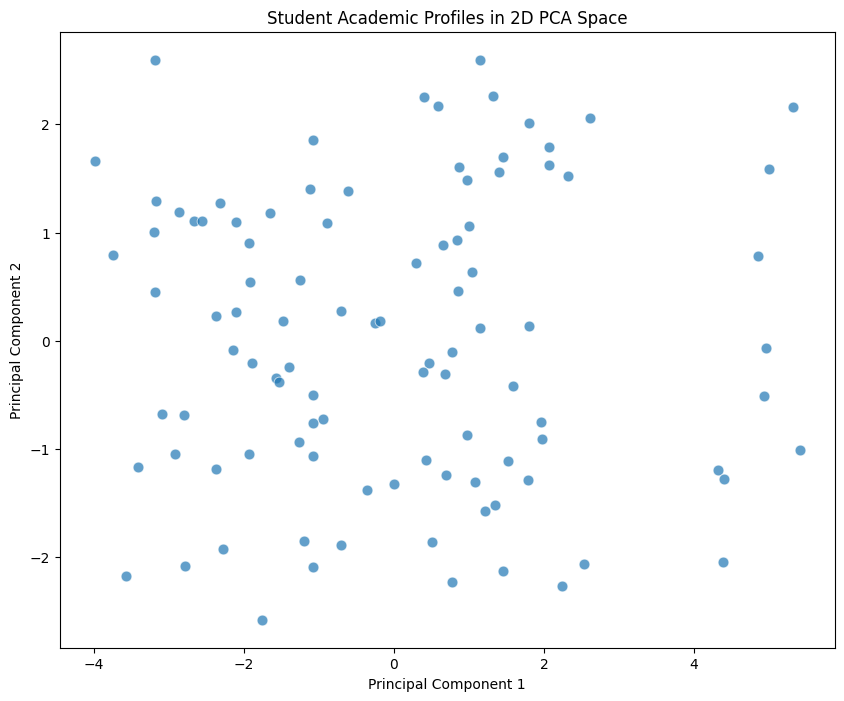

In [ ]:
# Create a figure and axes with a specified size
plt.figure(figsize=(10, 8))

sns.scatterplot(x='pc1', y='pc2', data=df_transformed, s=60, alpha=0.7)


plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Set the title
plt.title('Student Academic Profiles in 2D PCA Space')

plt.show()

##**Core Insights from PCA Space**
###**​1. Student Archetypes by Quadrant**

​The distribution across the two principal components allows us to categorize students into four distinct profiles:

**​Top-Right (All-Rounders):** High PC1 and High PC2. These students excel in both traditional core subjects (academics) and physical/creative activities (band/PE).

**​Bottom-Right (The "Studious" Type):** High PC1 but Low PC2. These students are academically strong but show less proficiency or interest in physical education or band.

**​Top-Left (The "Creative/Athletic" Type):** Low PC1 but High PC2. These students are highly proficient in physical or creative domains but may be struggling with core academic subjects.

**​Bottom-Left (At-Risk Performers):** Low PC1 and Low PC2. These students show lower proficiency across both academic and physical/creative parameters and likely require the most intervention.

###**​2. Variance and Distribution**
**​Broad Proficiency Range:** The wide spread of data points across the plot suggests a high degree of diversity in the student body. There isn't a single "typical" student profile; instead, proficiency varies significantly in both dimensions.

**​High Academic Achievers:** There is a specific cluster of high performers in core subjects (far right of the x-axis), though their excellence in secondary subjects (y-axis) fluctuates, showing that academic success doesn't always correlate with physical/creative success.